In [8]:
# https://www.kaggle.com/datasets/atilsamancioglu/imagewoof200

In [9]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "imagewoof200"

In [10]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [11]:
check_data(image_path)

# of directories: 2 and 3 images in 'imagewoof200'.
# of directories: 10 and 0 images in 'imagewoof200\test'.
# of directories: 0 and 48 images in 'imagewoof200\test\australian_terrier'.
# of directories: 0 and 48 images in 'imagewoof200\test\beagle'.
# of directories: 0 and 48 images in 'imagewoof200\test\border_terrier'.
# of directories: 0 and 48 images in 'imagewoof200\test\dingo'.
# of directories: 0 and 48 images in 'imagewoof200\test\english_foxhound'.
# of directories: 0 and 48 images in 'imagewoof200\test\golden_retriever'.
# of directories: 0 and 48 images in 'imagewoof200\test\old_english_sheepdog'.
# of directories: 0 and 48 images in 'imagewoof200\test\rhodesian_ridgeback'.
# of directories: 0 and 48 images in 'imagewoof200\test\samoyed'.
# of directories: 0 and 48 images in 'imagewoof200\test\shih_tzu'.
# of directories: 10 and 0 images in 'imagewoof200\train'.
# of directories: 0 and 200 images in 'imagewoof200\train\australian_terrier'.
# of directories: 0 and 200 image

In [12]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [13]:
train_dir

WindowsPath('imagewoof200/train')

In [14]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [15]:
manual_transforms = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.406],
                      std=[0.229, 0.224, 0.225])
])

In [16]:
NUM_WORKES = os.cpu_count()

def create_dataloaders(train_dir: str,
                       test_dir: str,
                       transform: transforms.Compose,
                       batch_size: int,
                       num_workers: int=NUM_WORKES):

  train_data = datasets.ImageFolder(root=train_dir, transform=transform)
  test_data = datasets.ImageFolder(root=test_dir, transform=transform)

  class_names = train_data.classes

  train_dataloader = DataLoader(dataset=train_data,
                                batch_size=batch_size,
                                shuffle=True,
                                num_workers=num_workers,
                                pin_memory=True)
  test_dataloader = DataLoader(dataset=test_data,
                                batch_size=batch_size,
                                shuffle=False,
                                num_workers=num_workers,
                                pin_memory=True)

  return train_dataloader, test_dataloader, class_names

In [17]:
import torchvision
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

In [18]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [19]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [20]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,
                                                                    test_dir=test_dir,
                                                                    transform=auto_transforms,
                                                                    batch_size=32)

In [21]:
train_dataloader

In [22]:
class_names

['australian_terrier',
 'beagle',
 'border_terrier',
 'dingo',
 'english_foxhound',
 'golden_retriever',
 'old_english_sheepdog',
 'rhodesian_ridgeback',
 'samoyed',
 'shih_tzu']

In [23]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [24]:
device

'cuda'

In [25]:
#weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [26]:
from torchinfo import summary

In [27]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [28]:
for param in model.features.parameters():
    param.requires_grad = False

In [29]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

In [30]:
summary(model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 10]             --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [31]:
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [32]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):

    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [33]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

results = train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

Epoch: 1 | train_loss: 1.3888 | train_acc: 0.6845 | test_loss: 0.7330 | test_acc: 0.8667
Epoch: 2 | train_loss: 0.6755 | train_acc: 0.8557 | test_loss: 0.5100 | test_acc: 0.8792
Epoch: 3 | train_loss: 0.5352 | train_acc: 0.8651 | test_loss: 0.4575 | test_acc: 0.8750
Epoch: 4 | train_loss: 0.4611 | train_acc: 0.8938 | test_loss: 0.4031 | test_acc: 0.8938
Epoch: 5 | train_loss: 0.4083 | train_acc: 0.8983 | test_loss: 0.4040 | test_acc: 0.8896


In [34]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [35]:
custom_image_path = data_path / "imagewoof200/golden.jpg"

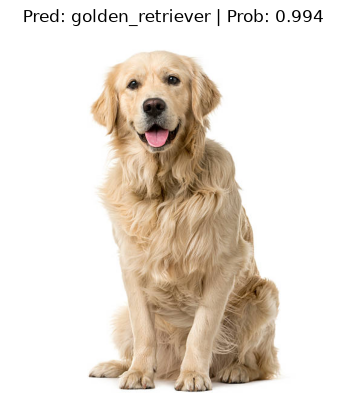

In [36]:
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

In [37]:
custom_image_path = data_path / "imagewoof200/foxhound.jpg"

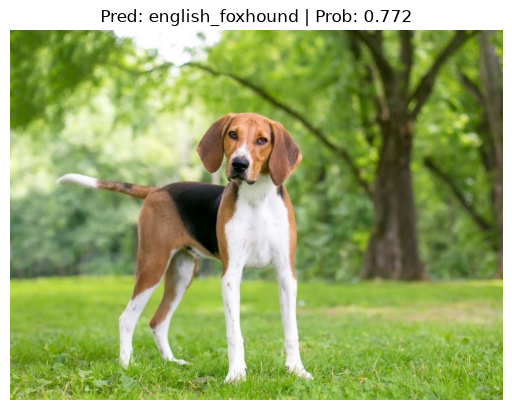

In [38]:
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

In [41]:
custom_image_path = data_path / "imagewoof200/samoyed.jpg"

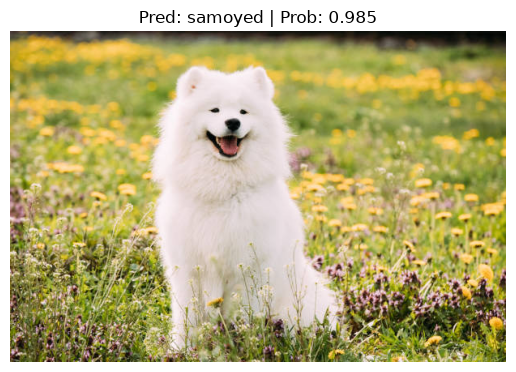

In [42]:
transform_predict(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)